In [1]:
import pandas as pd

# Read the Titanic training dataset
train_df = pd.read_csv('../lectures/HandsOn_Chapter3/datasets/titanic/train.csv')

# Display basic information about the dataset
print(f"Dataset shape: {train_df.shape}")
print(f"\nFirst few rows:")
train_df.head()

Dataset shape: (891, 12)

First few rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Exploration and Preparation

Let's explore the dataset and prepare it for modeling.

In [2]:
# Explore the dataset
print("Dataset Info:")
print(train_df.info())
print("\n" + "="*50 + "\n")
print("Statistical Summary:")
print(train_df.describe())
print("\n" + "="*50 + "\n")
print("Missing Values:")
print(train_df.isnull().sum())
print("\n" + "="*50 + "\n")
print("Survival Rate:")
print(train_df['Survived'].value_counts(normalize=True))

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


Statistical Summary:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699113    0.52

## Feature Engineering and Data Preprocessing

Prepare features for the classifier by handling missing values and encoding categorical variables.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np

# Create a copy for preprocessing
df = train_df.copy()

# Select features for modeling
# Drop PassengerId (just an ID), Name (too unique), Ticket (too unique), Cabin (too many missing values)
features_to_use = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

# Prepare features and target
X = df[features_to_use].copy()
y = df['Survived']

# Handle categorical variables
X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})
X['Embarked'] = X['Embarked'].fillna('S')  # Fill missing with most common
X = pd.get_dummies(X, columns=['Embarked'], drop_first=True)

# Impute missing Age values with median
age_imputer = SimpleImputer(strategy='median')
X['Age'] = age_imputer.fit_transform(X[['Age']])

# Impute missing Fare values with median
fare_imputer = SimpleImputer(strategy='median')
X['Fare'] = fare_imputer.fit_transform(X[['Fare']])

print("Preprocessed features:")
print(X.head())
print(f"\nFeature shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nAny missing values remaining: {X.isnull().sum().sum()}")

Preprocessed features:
   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0       3    0  22.0      1      0   7.2500       False        True
1       1    1  38.0      1      0  71.2833       False       False
2       3    1  26.0      0      0   7.9250       False        True
3       1    1  35.0      1      0  53.1000       False        True
4       3    0  35.0      0      0   8.0500       False        True

Feature shape: (891, 8)
Target shape: (891,)

Any missing values remaining: 0


## Train-Test Split

Split the data into training and testing sets.

In [4]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set survival rate: {y_train.mean():.3f}")
print(f"Test set survival rate: {y_test.mean():.3f}")

Training set size: 712
Test set size: 179

Training set survival rate: 0.383
Test set survival rate: 0.385


## Train Multiple Classifiers

Let's train several different classifiers and compare their performance.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

# Train and evaluate each classifier
results = {}

for name, clf in classifiers.items():
    # Train
    clf.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred_train = clf.predict(X_train_scaled)
    y_pred_test = clf.predict(X_test_scaled)
    
    # Calculate accuracy
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    
    results[name] = {
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'model': clf
    }
    
    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

# Display summary
print(f"\n{'='*60}")
print("Summary of Results")
print(f"{'='*60}")
results_df = pd.DataFrame({
    'Classifier': list(results.keys()),
    'Train Accuracy': [v['train_accuracy'] for v in results.values()],
    'Test Accuracy': [v['test_accuracy'] for v in results.values()]
})
print(results_df.sort_values('Test Accuracy', ascending=False))


Logistic Regression
Training Accuracy: 0.8076
Test Accuracy: 0.8045

Decision Tree
Training Accuracy: 0.9817
Test Accuracy: 0.8156

Random Forest
Training Accuracy: 0.9817
Test Accuracy: 0.8101

SVM
Training Accuracy: 0.8441
Test Accuracy: 0.8101

K-Nearest Neighbors
Training Accuracy: 0.8553
Test Accuracy: 0.8156

Summary of Results
            Classifier  Train Accuracy  Test Accuracy
1        Decision Tree        0.981742       0.815642
4  K-Nearest Neighbors        0.855337       0.815642
2        Random Forest        0.981742       0.810056
3                  SVM        0.844101       0.810056
0  Logistic Regression        0.807584       0.804469


## Detailed Evaluation of Best Model

Let's examine the best performing model in more detail.

In [6]:
# Get the best model
best_model_name = max(results, key=lambda k: results[k]['test_accuracy'])
best_model = results[best_model_name]['model']

print(f"Best Model: {best_model_name}")
print(f"\n{'='*60}")

# Make predictions
y_pred = best_model.predict(X_test_scaled)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Did not survive', 'Survived']))

# Confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print("\nConfusion Matrix Interpretation:")
print(f"True Negatives (correctly predicted did not survive): {cm[0,0]}")
print(f"False Positives (incorrectly predicted survived): {cm[0,1]}")
print(f"False Negatives (incorrectly predicted did not survive): {cm[1,0]}")
print(f"True Positives (correctly predicted survived): {cm[1,1]}")

Best Model: Decision Tree


Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.84      0.86      0.85       110
       Survived       0.77      0.74      0.76        69

       accuracy                           0.82       179
      macro avg       0.81      0.80      0.80       179
   weighted avg       0.81      0.82      0.81       179


Confusion Matrix:
[[95 15]
 [18 51]]

Confusion Matrix Interpretation:
True Negatives (correctly predicted did not survive): 95
False Positives (incorrectly predicted survived): 15
False Negatives (incorrectly predicted did not survive): 18
True Positives (correctly predicted survived): 51


## Feature Importance (for tree-based models)

If the best model is tree-based, we can examine which features are most important for prediction.

Feature Importances:
      Feature  Importance
1         Sex    0.316638
2         Age    0.252508
5        Fare    0.233430
0      Pclass    0.110281
7  Embarked_S    0.032651
4       Parch    0.029445
3       SibSp    0.019436
6  Embarked_Q    0.005611


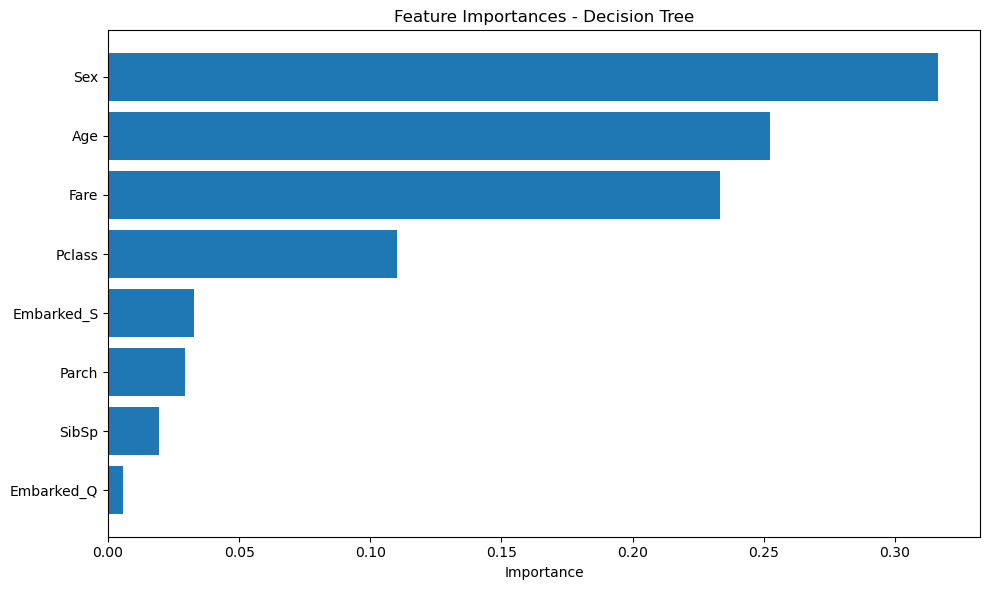

In [7]:
# Check if the best model has feature_importances_
if hasattr(best_model, 'feature_importances_'):
    # Get feature importances
    importances = best_model.feature_importances_
    feature_names = X.columns
    
    # Create a DataFrame for visualization
    feature_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print("Feature Importances:")
    print(feature_imp_df)
    
    # Plot feature importances
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(10, 6))
    plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'])
    plt.xlabel('Importance')
    plt.title(f'Feature Importances - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not provide feature importances.")
    print("Consider using a tree-based model (Decision Tree or Random Forest) to see feature importances.")